f:\Summer 26\Langchain and LangGraph\Myenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


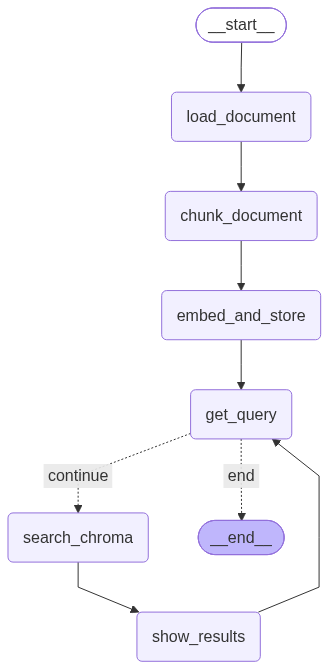

In [1]:
from pathlib import Path
from typing import TypedDict
from langgraph.graph import StateGraph, START,END
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_chroma import Chroma


class RAGState(TypedDict):
    file_path: str
    raw_text: str        
    chunks: list[str]     
    vectorstore: Chroma   
    query: str            
    results: list[str]


def load_document(state: RAGState) -> dict:
    """Node: reads the markdown file from disk."""
    text = Path(state["file_path"]).read_text(encoding="utf-8")
    return {"raw_text": text}


def chunk_document(state: RAGState, chunk_size: int = 1000, overlap: int = 100) -> dict:
    """Node: splits the raw text into fixed-size overlapping chunks."""
    text = state["raw_text"]
    chunks = []
    start = 0
    while start < len(text):
        end = start + chunk_size
        chunks.append(text[start:end])
        if end >= len(text):
            break
        start = end - overlap
    return {"chunks": [c for c in chunks if c.strip()]}

def embed_and_store(state: RAGState) -> dict:
    """Node: embeds all chunks and stores them in a Chroma vectorstore."""
    embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
    vectorstore = Chroma.from_texts(state["chunks"], embedding=embeddings)
    return {"vectorstore": vectorstore}

def get_query(state: RAGState) -> dict:
    """Node: prompts the user for a query (or 'exit' to quit)."""
    query = input("\nEnter a query (or 'exit' to quit): ")
    return {"query": query}

def check_exit(state: RAGState) -> str:
    """Router: decides whether to end the loop or continue to the search step."""
    if state["query"].strip().lower() in {"exit", "quit"}:
        return "end"
    return "continue"

def search_chroma(state: RAGState) -> dict:
    """ Node for searching our query (vector) in the chroma db"""
    results = state["vectorstore"].similarity_search(state["query"], k=3)
    return {"results": [r.page_content for r in results]}

def show_results(state: RAGState) -> dict:
    """Node: displays the top-k matching chunks to the user."""
    print("\n--- Top matches ---")
    for i, chunk in enumerate(state["results"], start=1):
        print(f"\n[{i}] {chunk}")
    print("\n")
    return {}


graph = StateGraph(RAGState)

graph.add_node("load_document", load_document)
graph.add_node("chunk_document", chunk_document)
graph.add_node("embed_and_store", embed_and_store)
graph.add_node("get_query", get_query)
graph.add_node("search_chroma", search_chroma)
graph.add_node("show_results", show_results)

graph.set_entry_point("load_document")
graph.add_edge("load_document", "chunk_document")
graph.add_edge("chunk_document", "embed_and_store")
graph.add_edge("embed_and_store", "get_query")
graph.add_edge("search_chroma", "show_results")
graph.add_conditional_edges(
    "get_query",
    check_exit,
    {
        "end": END,
        "continue": "search_chroma",
    }
)
graph.add_edge("show_results", "get_query")

workflow = graph.compile()
workflow
# final_state = workflow.invoke({'file_path': 'data.md'})
# # print(final_state)